# 🔐 Password Strength Prediction

### Machine Learning + NLP Project

This project analyzes password patterns and builds a machine learning model to classify passwords into three strength levels:

- **0 → Weak**
- **1 → Medium**
- **2 → Strong**

**Workflow:**  
Data Collection → Data Cleaning → EDA → Feature Engineering → NLP/TF-IDF → Model Training → Password Strength Prediction

# Getting Startred....

In [170]:
#import all the basic libraries ...
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Read the data from sql database...                                                                                                                                                                                                                                                                                             

In [171]:
import sqlite3

In [172]:
## u have your data into 'password_Data.sqlite' which has table  'Users' 
## now u can read data from this db file 'password_Data.sqlite' using sqlite3 & pandas

In [173]:
#first off all we have to create sql connection to the sql database
con = sqlite3.connect(r"password_data.sqlite")

In [174]:
'''check online its table name on https://sqliteonline.com/'''
data = pd.read_sql_query("SELECT * FROM  Users",con)

In [175]:
data.shape

(100000, 3)

In [176]:
data.head()

,index,password,strength
0,0,zxe870819,1
1,1,xw46454nr23l,1
2,2,soporte13,1
3,3,accounts6000webhost.com,2
4,4,c443balg,1


# 2.. Doing basic data cleaning !

In [177]:
data.columns

Index(['index', 'password', 'strength'], dtype='str')

### Removing ir-relevant features !

In [178]:
data.drop('index',axis = 1,inplace = True)

In [179]:
data.head()

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
3,accounts6000webhost.com,2
4,c443balg,1


### Check duplicate rows

In [180]:
data.duplicated().sum()

np.int64(0)

# check for missing values in the column....

In [181]:
data.isnull().sum()

password    0
strength    0
dtype: int64

In [182]:
data.isnull().any().sum() ## it means 0 feature have NAN value

np.int64(0)

# check datatype of every feature!

In [183]:
data.dtypes

password      str
strength    int64
dtype: object

### checking whether "strength" feature has ir-relevant values or not !

In [184]:
data['strength']

0        1
1        1
2        1
3        2
4        1
        ..
99995    1
99996    1
99997    1
99998    1
99999    1
Name: strength, Length: 100000, dtype: int64

In [185]:
data['strength'].unique()

array([1, 2, 0])

In [186]:
data['strength'].nunique()

3

# 3.. Performing Semantic Analysis !
    e.g ,,      
          
          a) How many password textual actually holds only numeric characters ?
          b) How many password textual actually holds only Upper-case character ? 
          
          c) How many password textual actually holds only alphabet ?
          d) How many password textual actually holds alpha-numeric character ? 
          e) How many password textual actually holds title-case character ? 
          
          f) How many password textual actually holds some special special character ? 

In [187]:
data.columns

Index(['password', 'strength'], dtype='str')

In [188]:
data['password']

0                      zxe870819
1                   xw46454nr23l
2                      soporte13
3        accounts6000webhost.com
4                       c443balg
                  ...           
99995                 obejofi215
99996                 fmiopvxb64
99997                  czvrbun38
99998                  mymyxe430
99999                glqjhkxb467
Name: password, Length: 100000, dtype: str

In [189]:
data['password'][0]

'zxe870819'

In [190]:
type(data['password'][0])

str

### a) How many password textual actually holds only numeric characters ?

In [191]:
data['password'].str.isnumeric()


0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: password, Length: 100000, dtype: bool

In [192]:
data[data['password'].str.isnumeric()]

,password,strength
12280,943801,0
14992,12345,0
20958,147856,0
21671,140290,0
23269,123987,0
28569,1233214,0
31329,0159456,0
32574,363761,0
37855,4524344,0
43648,5521597,0


In [193]:
data[data['password'].str.isnumeric()].shape # only 26 people hav eset their password as number according to this scenario

(26, 2)

### b) How many password textual actually holds only Upper-case character ? 

In [194]:
data[data['password'].str.isupper()]

,password,strength
115,EYT63119,1
273,INSPIRON6,1
338,1A2S3D4F,1
367,13269123A,1
373,YAMAZAKI82,1
...,...,...
99590,V13000993J,1
99692,65925013ABC,1
99784,01EDD055,1
99893,1UPONYOU,1


In [195]:
data[data['password'].str.isupper()].shape

(1506, 2)

### c) How many password textual actually holds only alphabet ? 

In [196]:
data['password'].str.isalpha()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: password, Length: 100000, dtype: bool

In [197]:
data[data['password'].str.isalpha()].shape

(50, 2)

### d) How many password textual actually holds alpha-numeric character ? 

In [198]:
data['password'].str.isalnum()

0         True
1         True
2         True
3        False
4         True
         ...  
99995     True
99996     True
99997     True
99998     True
99999     True
Name: password, Length: 100000, dtype: bool

In [199]:
data[data['password'].str.isalnum()].shape

(97203, 2)

### e) How many password textual actually holds title-case character ? 

In [200]:
data['password'].str.istitle()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: password, Length: 100000, dtype: bool

In [201]:
data[data['password'].str.istitle()].shape

(932, 2)

### f) How many password textual actually holds special character ? 

In [202]:
data['password']


0                      zxe870819
1                   xw46454nr23l
2                      soporte13
3        accounts6000webhost.com
4                       c443balg
                  ...           
99995                 obejofi215
99996                 fmiopvxb64
99997                  czvrbun38
99998                  mymyxe430
99999                glqjhkxb467
Name: password, Length: 100000, dtype: str

In [203]:
import string

In [204]:
string.punctuation ## all punctuations defined in "string" package !

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [205]:
def find_semantics(row):
    for char in row:
        if char in string.punctuation:
            return 1
        else:
            return 0
        

In [206]:
data['password'].apply(find_semantics)== 1

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: password, Length: 100000, dtype: bool

In [207]:
data[data['password'].apply(find_semantics)== 1]

,password,strength
192,<html>13476590nosD,2
4218,!@#testdevdomain1,2
6915,]/=[;.,0
12897,*110528#,1
33035,*171078*,1
34621,@28031978,1
37196,*********33,1
39145,$j8g0R12218001,2
44007,``````,0
61825,@ytu9z3pigx3c9m@,2


In [208]:
data[data["password"].apply(find_semantics)==1]

,password,strength
192,<html>13476590nosD,2
4218,!@#testdevdomain1,2
6915,]/=[;.,0
12897,*110528#,1
33035,*171078*,1
34621,@28031978,1
37196,*********33,1
39145,$j8g0R12218001,2
44007,``````,0
61825,@ytu9z3pigx3c9m@,2


In [209]:
data[data["password"].apply(find_semantics)==1].shape
## ie , 2663 observations have special characters in between them ..
## 2.6% people password actually uses special character in their password ..
## and contains 19 rows and have 2 columns

(19, 2)

## 4.. Applying Feature Engineering !

In [210]:
'''

we have password strength so you can do a quick google search to check what features password depends on:-
It depends on 5 factors :

    Length of password
    Frequency of Lowercase Characters
    Frequency of Uppercase Characters
    Frequency of Numeric Characters
    Frequency of Special Characters

These will be the result of the google search to find factors effecting strength of password..


'''

'\n\nwe have password strength so you can do a quick google search to check what features password depends on:-\nIt depends on 5 factors :\n\n    Length of password\n    Frequency of Lowercase Characters\n    Frequency of Uppercase Characters\n    Frequency of Numeric Characters\n    Frequency of Special Characters\n\nThese will be the result of the google search to find factors effecting strength of password..\n\n\n'

#### length of every password

In [211]:
data['password'][0]

'zxe870819'

In [212]:
len(data['password'][0])

9

In [213]:
data['length'] = data['password'].str.len()

#### Frequency of Lowercase Characters :

In [214]:
password = "shan99"

In [215]:
[char for char in password if char.islower()]

['s', 'h', 'a', 'n']

In [216]:
len([char for char in password if char.islower()])

4

In [217]:
len([char for char in password if char.islower()])/len(password)

0.6666666666666666

In [218]:
'''

Q..->> why we are diving each value by its Total length or why we are normalizing frequency ? 

Ans : Just  to get rid of some outliers bcz some passwords have huge length as we have seen , hence value of lowercase could 
also be high , so lets normalise it in the range between 0 to 1


'''

'\n\nQ..->> why we are diving each value by its Total length or why we are normalizing frequency ? \n\nAns : Just  to get rid of some outliers bcz some passwords have huge length as we have seen , hence value of lowercase could \nalso be high , so lets normalise it in the range between 0 to 1\n\n\n'

In [219]:
def freq_lowercase(row):
    return len([char for char in row if char.islower()])/len(row)

#### Frequency of Uppercase Characters :

In [220]:
def freq_uppercase(row):
    return len([char for char in row if char.isupper()])/len(row)

#### Frequency of Numeric Characters :

In [221]:
def freq_numeric_char(row):
    return len([char for char in row if char.isdigit()])/len(row)

In [222]:
### applying user-defined functions ..

In [223]:
data['lowercase_freq']  = np.round(data['password'].apply(freq_lowercase),3)
data['Uppercase_freq'] = np.round(data['password'].apply(freq_uppercase),3)
data['Numeric_char_freq'] = np.round(data['password'].apply(freq_numeric_char),3)

In [224]:
data.head(10)

,password,strength,length,lowercase_freq,Uppercase_freq,Numeric_char_freq
0,zxe870819,1,9,0.333,0.0,0.667
1,xw46454nr23l,1,12,0.417,0.0,0.583
2,soporte13,1,9,0.778,0.0,0.222
3,accounts6000webhost.com,2,23,0.783,0.0,0.174
4,c443balg,1,8,0.625,0.0,0.375
5,16623670p,1,9,0.111,0.0,0.889
6,yj9q3f8p,1,8,0.625,0.0,0.375
7,180ZIRUVIcuFERy,2,15,0.200,0.6,0.200
8,djredd09,1,8,0.750,0.0,0.250
9,yin172015,1,9,0.333,0.0,0.667


#### Frequency of Special-case Characters :

In [225]:
def special_char_freq(row):
    special_char = []
    for char in row:
        if not char.isalpha() and not char.isdigit():
            special_char.append(char)
    return len(special_char)
    

In [226]:
data['special_char_freq'] = np.round(data['password'].apply(special_char_freq),3)

In [227]:
data.head()

,password,strength,length,lowercase_freq,Uppercase_freq,Numeric_char_freq,special_char_freq
0,zxe870819,1,9,0.333,0.0,0.667,0
1,xw46454nr23l,1,12,0.417,0.0,0.583,0
2,soporte13,1,9,0.778,0.0,0.222,0
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,1
4,c443balg,1,8,0.625,0.0,0.375,0


## 5.. Performing Descriptive Statistics !

In [228]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

In [229]:
data[['length','strength']].groupby('strength').agg(['min','max','mean','median'])

length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0

In [230]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

In [231]:
cols = ['length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq']
for col in cols:
    print(col)
    print(data[[col,'strength']].groupby('strength').agg(['min','max','mean','median']))
    print('\n')

length
         length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0


lowercase_freq
         lowercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.708050  0.714
1                   0.0  0.923  0.630067  0.667
2                   0.0  0.917  0.424679  0.400


Uppercase_freq
         Uppercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.012872  0.000
1                   0.0  0.923  0.007915  0.000
2                   0.0  0.889  0.367633  0.429


Numeric_char_freq
         Numeric_char_freq                        
                       min    max      mean median
strength                   

In [232]:
'''

Just taking a rough look at the above stats I can say the following:-



->> Higher the length, Higher the strength

->> In case on alphabet frequency higher is not better. 
    Probably because it'll not be a strong password if max portion is occupied by just alphabets..
    Password has more strength if the char types are spread in decent proportions.



'''

"\n\nJust taking a rough look at the above stats I can say the following:-\n\n\n\n->> Higher the length, Higher the strength\n\n->> In case on alphabet frequency higher is not better. \n    Probably because it'll not be a strong password if max portion is occupied by just alphabets..\n    Password has more strength if the char types are spread in decent proportions.\n\n\n\n"

In [233]:
#### Similarly , if u need viz representation of above output : (u can refer boxplot)
## bcz boxplot basically gives us 5-point summary of data !

In [234]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

<Axes: xlabel='strength', ylabel='strength'>

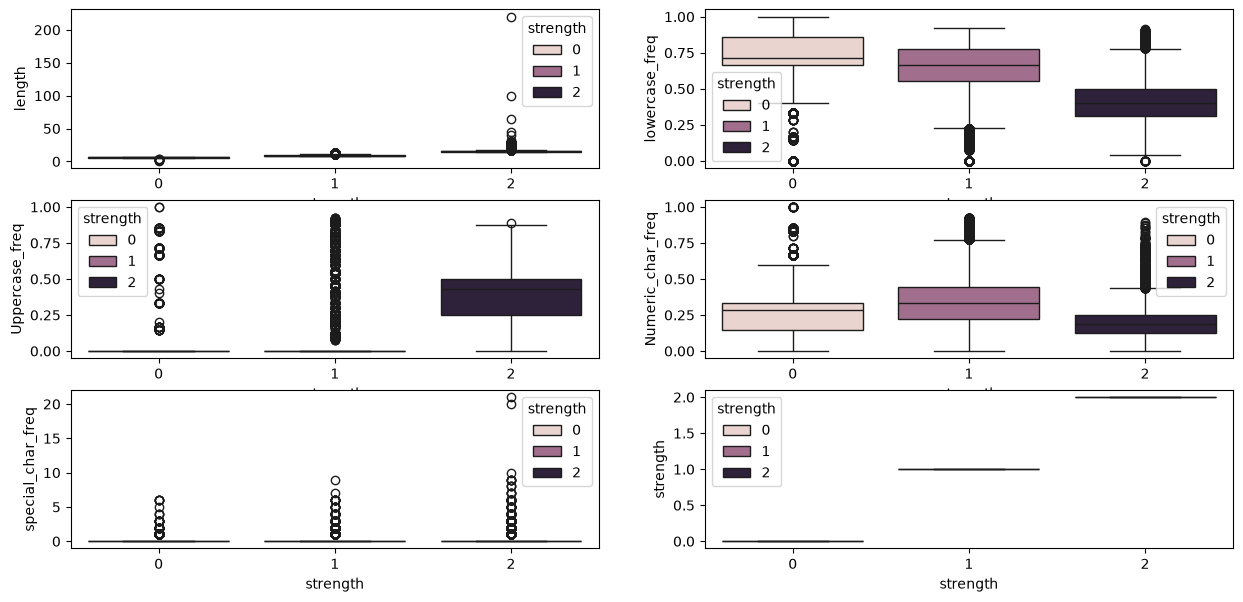

In [235]:
fig,((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(3,2,figsize = (15,7))

sns.boxplot(x = 'strength',y = 'length',hue = 'strength',ax = ax1,data=data)
sns.boxplot(x = 'strength',y = 'lowercase_freq', hue = 'strength',ax = ax2,data=data)
sns.boxplot(x = 'strength',y = 'Uppercase_freq', hue = 'strength',ax = ax3,data=data)
sns.boxplot(x = 'strength',y = 'Numeric_char_freq', hue = 'strength',ax = ax4, data=data)
sns.boxplot(x = 'strength',y = 'special_char_freq' ,hue = 'strength',ax = ax5,data=data)
sns.boxplot(x = 'strength',y = 'strength' ,hue = 'strength',ax = ax6,data=data)

In [236]:
'''
Insights :
Regarding the insights we can say that:-



->> Higher Lowercase frequency is seen in low strength passwords. 
    For higher strength passwords ,  Lowercase frequency can be high too but that is probably effect of length.


->> In digit_freq there is a split of majority poplutation of strength 1 and 2 
    but for 0 and 1 strength , there is overlap so no too much to say there. 
    But we can say a nicely propotioned password is good..
    
    
->> In upper_freq , there is a trend but not as strong as length or lower_freq..
    
    
->> Similar but stronger same trend as above in special_freq.

->> Higher strength passwords have more type breaks.


'''

'\nInsights :\nRegarding the insights we can say that:-\n\n\n\n->> Higher Lowercase frequency is seen in low strength passwords. \n    For higher strength passwords ,  Lowercase frequency can be high too but that is probably effect of length.\n\n\n->> In digit_freq there is a split of majority poplutation of strength 1 and 2 \n    but for 0 and 1 strength , there is overlap so no too much to say there. \n    But we can say a nicely propotioned password is good..\n\n\n->> In upper_freq , there is a trend but not as strong as length or lower_freq..\n\n\n->> Similar but stronger same trend as above in special_freq.\n\n->> Higher strength passwords have more type breaks.\n\n\n'

## 6.. Feature Importance ! ( How to figure out imp. feature )

In [237]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

In [238]:
def get_dist(data , feature):
    
    plt.figure(figsize=(10,8))
    plt.subplot(1,2,1)
    
    sns.violinplot(x='strength' , y=feature , data=data )
    
    plt.subplot(1,2,2)
    
    sns.distplot(data[data['strength']==0][feature] , color="red" , label="0" , hist=False)
    sns.distplot(data[data['strength']==1][feature], color="blue", label="1", hist=False)
    sns.distplot(data[data['strength']==2][feature], color="orange", label="2", hist=False)
    plt.legend()
    plt.show()

In [239]:
import warnings 
from warnings import filterwarnings
filterwarnings("ignore")

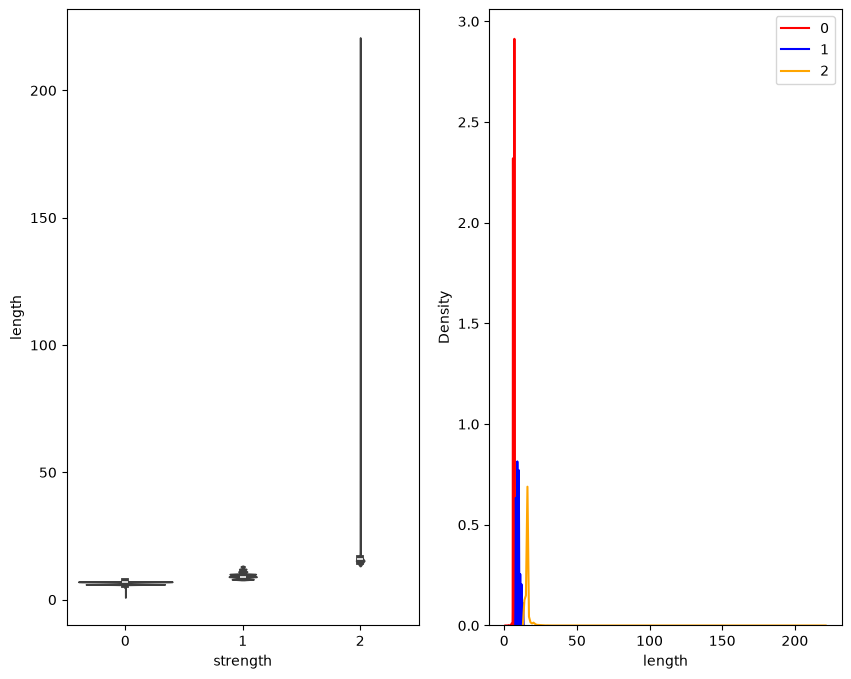

In [240]:
get_dist(data,"length")

In [241]:
### we have few overlappping region in distribution plot 
### when class is 2 , we have higher value of 'length' than class 1 & class 0

## it means 'length' is a interesting feature as we have very less overlapping region

## similarly from violinplot ,we will say on account of less overlappping , 
## this feature 'length' is amazing & useful in determining the strength

In [242]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

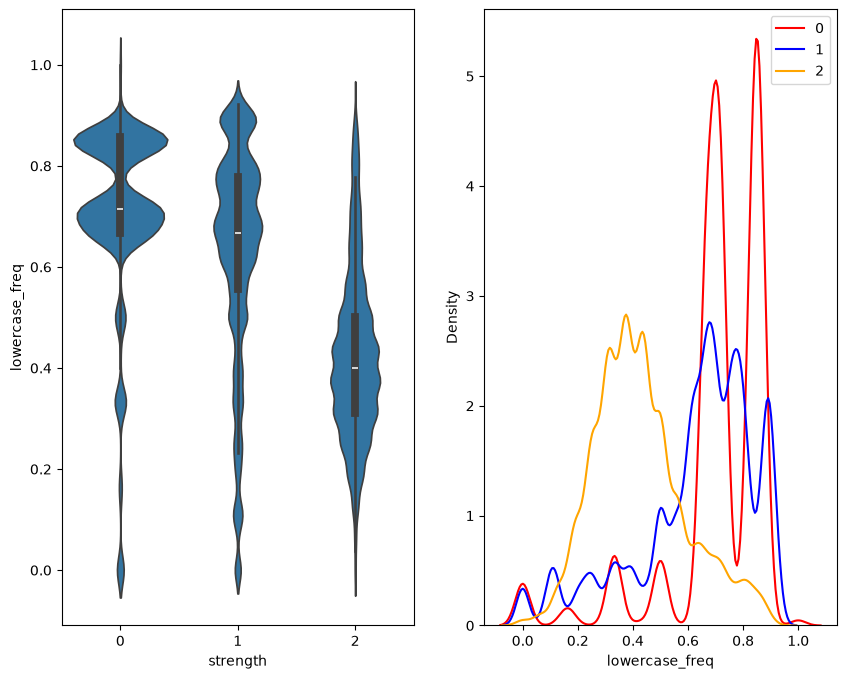

In [243]:
get_dist(data,'lowercase_freq')

In [244]:
### we have some kind of overlappping region in distribution plot 
### when class is 2 , we have less value of 'lower_freq' than class 1 & class 0

## it means 'lower_freq' is a interesting feature upto some extent as have some overlapping region

## similarly from violinplot ,we will say on account of such overlappping , 
## when class is 2 we have less value of 'lower_freq' than class 1 & class 0
## this feature 'lower_freq' is a interesting feature upto some extent in determining the strength

In [245]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

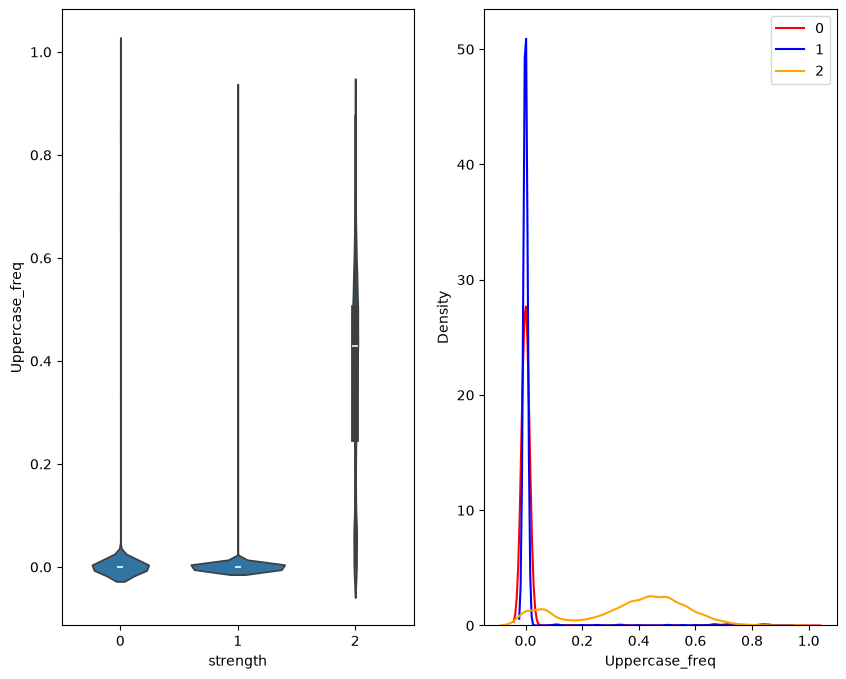

In [246]:
get_dist(data,'Uppercase_freq')

In [247]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

In [248]:
### we have quite high overlappping region in distribution plot 

## it means 'upper_freq' is not that much interesting feature as have some overlapping region

## similarly from violinplot ,we will say on account of such huge overlappping , 
## this feature 'lower_freq' is not a interesting feature in determining the strength

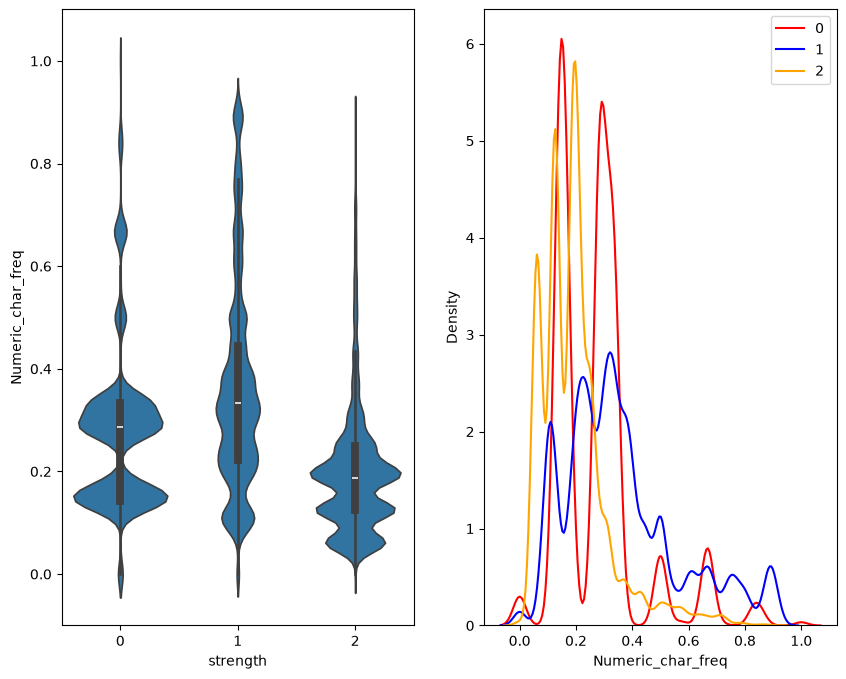

In [249]:
get_dist(data,'Numeric_char_freq')

In [250]:
data.columns

Index(['password', 'strength', 'length', 'lowercase_freq', 'Uppercase_freq',
       'Numeric_char_freq', 'special_char_freq'],
      dtype='str')

In [251]:
### we have quite high overlappping region in distribution plot 

## it means 'upper_freq' is not that much interesting feature as have some overlapping region

## similarly from violinplot ,we will say on account of such huge overlappping , 
## this feature 'lower_freq' is not a interesting feature in determining the strength

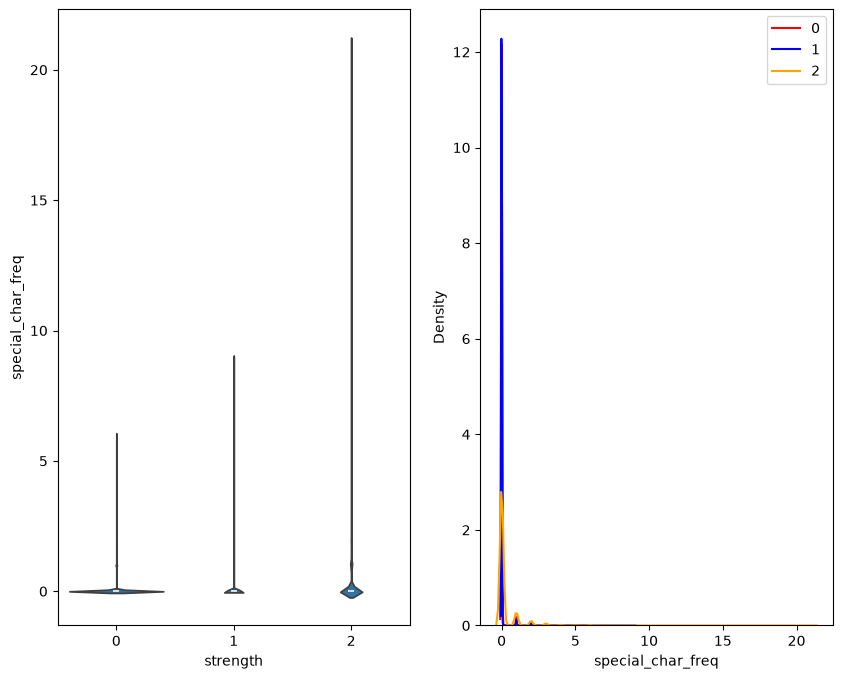

In [252]:
get_dist(data,'special_char_freq')

## 7.. Applying TF_IDF on data

In [253]:
data.head()

,password,strength,length,lowercase_freq,Uppercase_freq,Numeric_char_freq,special_char_freq
0,zxe870819,1,9,0.333,0.0,0.667,0
1,xw46454nr23l,1,12,0.417,0.0,0.583,0
2,soporte13,1,9,0.778,0.0,0.222,0
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,1
4,c443balg,1,8,0.625,0.0,0.375,0


In [254]:
data

,password,strength,length,lowercase_freq,Uppercase_freq,Numeric_char_freq,special_char_freq
0,zxe870819,1,9,0.333,0.0,0.667,0
1,xw46454nr23l,1,12,0.417,0.0,0.583,0
2,soporte13,1,9,0.778,0.0,0.222,0
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,1
4,c443balg,1,8,0.625,0.0,0.375,0
...,...,...,...,...,...,...,...
99995,obejofi215,1,10,0.700,0.0,0.300,0
99996,fmiopvxb64,1,10,0.800,0.0,0.200,0
99997,czvrbun38,1,9,0.778,0.0,0.222,0
99998,mymyxe430,1,9,0.667,0.0,0.333,0


In [255]:
#I shuffled the data to make the ML model robust(Robust = strong and reliable, not easily affected by small changes or problems)
dataframe = data.sample(frac=1)

In [256]:
dataframe

,password,strength,length,lowercase_freq,Uppercase_freq,Numeric_char_freq,special_char_freq
74205,733DAtefOXYQuW,2,14,0.286,0.500,0.214,0
77282,gg051014mm,1,10,0.400,0.000,0.600,0
28403,pxhdovlk1,1,9,0.889,0.000,0.111,0
40181,u92E02cF4AR38z2D,2,16,0.188,0.312,0.500,0
65397,ypydeqy688,1,10,0.700,0.000,0.300,0
...,...,...,...,...,...,...,...
44267,1742matty,1,9,0.556,0.000,0.444,0
49110,zxfmwdu502,1,10,0.700,0.000,0.300,0
62288,layna030306,1,11,0.455,0.000,0.545,0
18,konjina88,1,9,0.778,0.000,0.222,0


In [271]:
x = list(dataframe['password'])

In [272]:
x

['733DAtefOXYQuW',
 'gg051014mm',
 'pxhdovlk1',
 'u92E02cF4AR38z2D',
 'ypydeqy688',
 'aquariahere1',
 'MSEue3zM4NAGEvTA',
 'vladek13',
 'koketso@tebogo1',
 'stekepanne10',
 'ha2861995',
 'tqs5biyq',
 'melissa147',
 'most30',
 'CuwMwUzQwNArq0hj',
 'qwerty1998',
 'fusvklqgt32',
 'uPLDNETQxMAJg67J',
 'fuckda123',
 '123456mat',
 'steryd1',
 'cando44',
 'gremio07',
 'perro2010',
 'OeEO2vDQyNwWaACi',
 'gool2006',
 '96851130r',
 'tiger1962',
 'aresuo045',
 'bvch1zu12fm5',
 'ygx880528',
 'banjaran123',
 'stars13',
 'doxodow365',
 'ync7106243',
 'najiamati2',
 'postb1',
 'pump10up',
 'singh@1987101428',
 'iaykdsmv079',
 'zBsmU3zE5NAceROp',
 'xljrqkpya7',
 'qmrjpgln4',
 'DYv41JDI0Mwg7cBC',
 'lospinos180',
 'juanbeto01',
 'kurang4sem',
 'ashley111',
 'futuro000',
 'a30c17f14',
 'vagizafa13',
 'XnwYPIDM5OA4In4x',
 'ekimi333',
 '09131934kl',
 'gzmdgv9',
 'pgl9rmh',
 'njoptkp23',
 'ununu868',
 'nzfcvpmor521',
 'fa11022010',
 'na2170211',
 'berlin200',
 'qoleda135',
 'mlgwar2327',
 'yeahyeah1',
 'vil

In [273]:
from sklearn.feature_extraction.text import TfidfVectorizer## import TF-IDF vectorizer to convert text data into numerical data

In [274]:
#### as password is a series of chars , we have to calculate TF_IDF values of each char 
#### Thats why we have to split our password as-->>
#### kzde5577-->> ['k', 'z', 'd', 'e', '5', '5', '7', '7']


### then we can compute Tf-Idf value of each character like Tf-IDF value of k , Tf-IDF value of z


In [275]:
vectorizer = TfidfVectorizer(analyzer='char')

In [276]:
X  = vectorizer.fit_transform(x)